# Mini-CNN für Shapes

Ein kleines Faltungsnetz unterscheidet Quadrate von Dreiecken. Es bekommt nur Pixel — worauf es achtet, lernt es selbst.

1. Bilder als Tensor laden (256 → 64 px, pro Bild normalisiert)
2. Training mit Lernkurve
3. Demo: Wichtigkeits-Heatmap, Filter-Ansicht, Schieberegler
4. Eigenes Bild testen

torch CPU-only, kein torchvision — die PNGs lädt PIL.

In [194]:
import os
# ponytail: Anaconda (MKL) und torch bringen beide libiomp5md.dll mit -> Abbruch beim Import.
# Muss VOR dem torch-Import stehen. Sauberere Alternative: torch/lib/libiomp5md.dll löschen,
# dann nutzt torch Anacondas Kopie - kommt aber bei jedem torch-Update zurück.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

torch.manual_seed(0)
DATA, GROESSE = Path("shapes_dataset"), 64
KLASSEN = ["triangle", "square"]           # Index 0 / 1

pfade, y = [], []
for ordner, label in [("squares", 1), ("triangles", 0)]:
    for p in sorted((DATA/ordner).glob("*.png")):
        pfade.append(p); y.append(label)
pfade = np.array(pfade)

def lade(pfad):
    a = np.asarray(Image.open(pfad).convert("L").resize((GROESSE, GROESSE)),
                   dtype=np.float32)
    return (a - a.mean()) / (a.std() + 1e-6)   # pro Bild normalisiert -> Helligkeit egal

X = torch.tensor(np.stack([lade(p) for p in pfade]))[:, None]   # (100, 1, 64, 64)
Y = torch.tensor(y)

rng = np.random.default_rng(0)
mischung = rng.permutation(len(X))
train = torch.tensor(mischung[:70]); test = torch.tensor(mischung[70:])
print(f"{tuple(X.shape)}  |  {len(train)} Train, {len(test)} Test")

(100, 1, 64, 64)  |  70 Train, 30 Test


## 1. Das Netz

- `Conv2d(1, 4, 3)` — 4 Filter der Größe 3×3 fahren über das Bild. Jeder lernt selbst, worauf er anspringt (Kanten, Ecken, …). Die Zahl links muss immer die Ausgangszahl der Schicht davor sein: 1 → 4 → 8 → 16 → 32.
- `MaxPool2d(2)` — halbiert die Auflösung: 64 → 32 → 16 → 8 → 4. Nicht überspringen, sondern zusammenfassen: aus jedem 2×2-Block bleibt der **größte** Wert. Deshalb überlebt eine Kante auch dann, wenn sie sich um ein Pixel verschiebt.
- `mean((2,3))` — jeder der 32 Kanäle wird zu **einer** Zahl gemittelt. Damit ist die Position egal, nur „wie stark kommt Muster X vor" zählt.
- `LazyLinear(2)` — der Kopf. Nur die 2 für die Klassen wird angegeben, die Eingangszahl holt sich PyTorch beim ersten Bild selbst.

**Poolen kostet Bild.** Jedes `MaxPool2d(2)` halbiert, jedes `MaxPool2d(4)` viertelt. Bei 64 px sind das höchstens sechs Halbierungen oder drei Viertelungen — danach ist die Karte 1×1 und es kommt `Output size is too small`.

In [195]:
class MiniCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.merkmale = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1),   nn.ReLU(), nn.MaxPool2d(8),   # 64 -> 32
            nn.Conv2d(4, 8, 3, padding=1),   nn.ReLU(), nn.MaxPool2d(8), 
            
        )
        # LazyLinear holt sich die Eingangszahl (hier 32) beim ersten Bild selbst.
        # Damit muss man beim Umbauen der Kanaele nichts nachziehen.
        self.kopf = nn.LazyLinear(2)

    def forward(self, x):
        k = self.merkmale(x)
        return self.kopf(k.mean((2, 3)))          # Global Average Pooling

modell = MiniCNN()
modell(X[:1])                                     # ein Bild, damit LazyLinear sich festlegt
anzahl = sum(p.numel() for p in modell.parameters())
print(modell)
print(f"\nKarte vor dem Kopf: {tuple(modell.merkmale(X[:1]).shape)}")
print(f"Parameter: {anzahl}")

MiniCNN(
  (merkmale): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  )
  (kopf): Linear(in_features=8, out_features=2, bias=True)
)

Karte vor dem Kopf: (1, 8, 1, 1)
Parameter: 354


## 2. Training

70 Bilder passen in einen Batch — kein DataLoader nötig. 80 Epochen Adam.

In [196]:
opt = torch.optim.Adam(modell.parameters(), lr=0.01)
verlust_fn = nn.CrossEntropyLoss()

def genauigkeit(teil):
    modell.eval()
    with torch.no_grad():
        return (modell(X[teil]).argmax(1) == Y[teil]).float().mean().item()

verlauf = []
for epoche in range(80):
    modell.train()
    opt.zero_grad()
    verlust = verlust_fn(modell(X[train]), Y[train])
    verlust.backward(); opt.step()
    verlauf.append((verlust.item(), genauigkeit(train), genauigkeit(test)))
    if epoche % 20 == 19:
        v, tr, te = verlauf[-1]
        print(f"Epoche {epoche+1:3d}  Verlust {v:.4f}  Train {tr*100:5.1f}%  Test {te*100:5.1f}%")

print(f"\nEndstand Test: {genauigkeit(test)*100:.1f}%")

Epoche  20  Verlust 0.0909  Train 100.0%  Test 100.0%
Epoche  40  Verlust 0.0005  Train 100.0%  Test 100.0%
Epoche  60  Verlust 0.0001  Train 100.0%  Test 100.0%
Epoche  80  Verlust 0.0001  Train 100.0%  Test 100.0%

Endstand Test: 100.0%


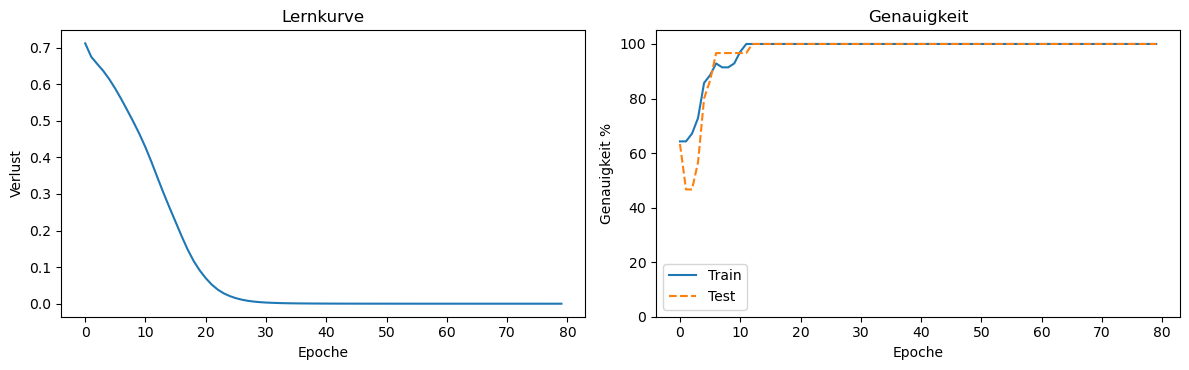

In [197]:
verlauf = np.array(verlauf)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(verlauf[:, 0]); a1.set(xlabel="Epoche", ylabel="Verlust", title="Lernkurve")
a2.plot(verlauf[:, 1]*100, label="Train")
a2.plot(verlauf[:, 2]*100, ls="--", label="Test")
a2.set(xlabel="Epoche", ylabel="Genauigkeit %", title="Genauigkeit", ylim=(0, 105))
a2.legend(); plt.tight_layout(); plt.show()

## 3. Wo schaut das Netz hin?

Ein graues Kästchen über das Bild schieben und messen, wie stark die Sicherheit einbricht. Großer Einbruch = dort stand etwas Entscheidendes.

In [198]:
def wichtigkeit(x, klasse, kachel=16, schritt=4):
    """Heatmap: wie stark fällt die Wahrscheinlichkeit, wenn man diese Stelle zuhält?"""
    modell.eval()
    with torch.no_grad():
        basis = modell(x[None]).softmax(1)[0, klasse].item()
        stapel, orte = [], []
        for i in range(0, GROESSE - kachel + 1, schritt):
            for j in range(0, GROESSE - kachel + 1, schritt):
                z = x.clone(); z[:, i:i+kachel, j:j+kachel] = 0.0   # 0 = Mittelwert
                stapel.append(z); orte.append((i, j))
        werte = modell(torch.stack(stapel)).softmax(1)[:, klasse].numpy()

    karte = np.zeros((GROESSE, GROESSE)); zaehler = np.zeros((GROESSE, GROESSE))
    for (i, j), wert in zip(orte, werte):
        karte[i:i+kachel, j:j+kachel] += basis - wert               # Einbruch
        zaehler[i:i+kachel, j:j+kachel] += 1
    return karte / np.maximum(zaehler, 1)

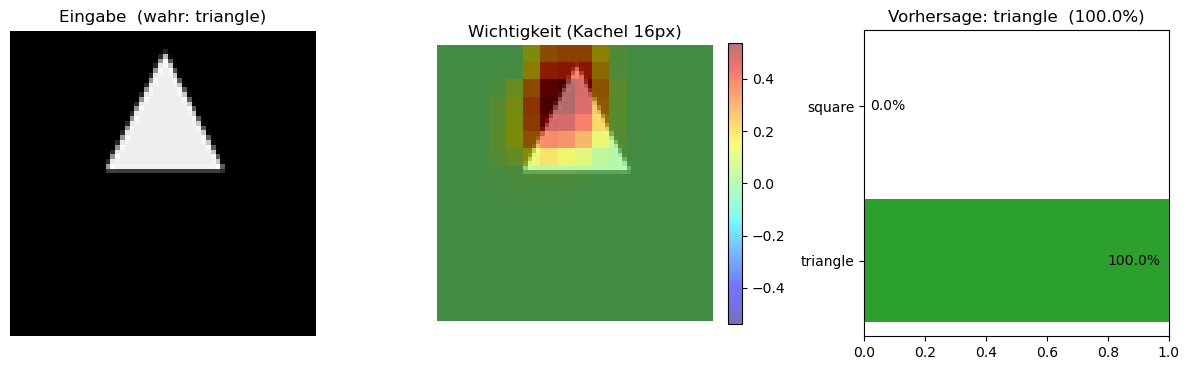

In [199]:
def zeige_cnn(idx, kachel=16, achsen=None):
    x = X[idx]
    modell.eval()
    with torch.no_grad():
        p = modell(x[None]).softmax(1)[0].numpy()
    klasse = int(p.argmax())
    wahrheit = pfade[idx].parent.name[:-1]
    roh = np.asarray(Image.open(pfade[idx]).convert("L").resize((GROESSE, GROESSE)))

    a1, a2, a3 = achsen if achsen is not None else plt.subplots(1, 3, figsize=(12, 3.8))[1]

    a1.imshow(roh, cmap="gray"); a1.axis("off")
    a1.set_title(f"Eingabe  (wahr: {wahrheit})")

    karte = wichtigkeit(x, klasse, kachel)
    a2.imshow(roh, cmap="gray")
    bild = a2.imshow(karte, cmap="jet", alpha=.55,
                     vmin=-abs(karte).max(), vmax=abs(karte).max())
    a2.axis("off"); a2.set_title(f"Wichtigkeit (Kachel {kachel}px)")
    plt.colorbar(bild, ax=a2, fraction=.046)

    farben = ["tab:green" if KLASSEN[k] == wahrheit else "tab:red" for k in (0, 1)]
    a3.barh(KLASSEN, p, color=farben)
    a3.set(xlim=(0, 1), title=f"Vorhersage: {KLASSEN[klasse]}  ({p[klasse]*100:.1f}%)")
    for k, v in enumerate(p):
        a3.text(min(v + .02, .8), k, f"{v*100:.1f}%", va="center")
    return p

zeige_cnn(int(test[0])); plt.tight_layout(); plt.show()

### Die Filter — erst die erste Schicht, dann alle

**`zeige_filter`** zeigt für die **erste** Schicht beides: oben den Filter selbst (3×3 Gewichte), unten seine Antwort auf das Bild.

**`zeige_schichten`** zeigt die Antworten **jeder** Faltungsschicht, also 4 + 8 + 16 + 32 Karten.

Warum bei den tieferen Schichten keine Gewichte zu sehen sind: `conv1` bekommt ein Graustufenbild, jeder seiner Filter ist also genau eine 3×3-Tabelle — die lässt sich als Bild zeigen. `conv2` bekommt 4 Kanäle, jeder Filter dort ist ein Stapel aus vier 3×3-Tabellen, `conv4` sogar aus sechzehn. Das ist kein Bild mehr, sondern ein Würfel aus Zahlen. Anschaulich bleiben nur die **Antworten**.

Und die werden nach unten hin gröber: 64×64 in der ersten Schicht, 4×4 in der letzten. Das ist Absicht — vorne einzelne Kanten, hinten „irgendwo hier oben links ist etwas Eckiges". Bei 4×4 sieht man keine Form mehr, sondern nur noch, in welcher Ecke etwas los war.

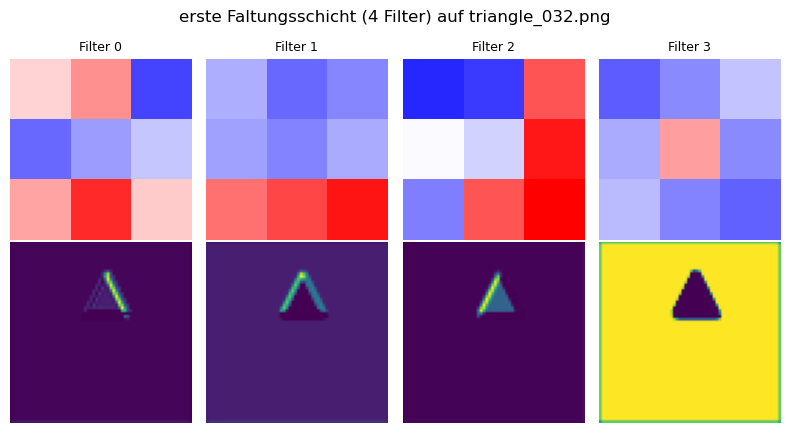

In [200]:
def zeige_filter(idx):
    conv1 = modell.merkmale[0]
    n = conv1.out_channels                                  # statt fester 8 - passt sich an
    with torch.no_grad():
        antwort = torch.relu(conv1(X[idx][None]))[0]        # (n, 64, 64)
    gewichte = conv1.weight.detach()[:, 0]                  # (n, 3, 3)

    fig, axs = plt.subplots(2, n, figsize=(2 * n, 4.4), squeeze=False)
    for k in range(n):
        axs[0, k].imshow(gewichte[k], cmap="bwr",
                         vmin=-gewichte.abs().max(), vmax=gewichte.abs().max())
        axs[0, k].set_title(f"Filter {k}", fontsize=9)
        axs[1, k].imshow(antwort[k], cmap="viridis")
        for a in (axs[0, k], axs[1, k]):
            a.axis("off")
    fig.suptitle(f"erste Faltungsschicht ({n} Filter) auf {pfade[idx].name}")
    plt.tight_layout(); plt.show()

zeige_filter(int(train[0]))

Bild: triangle_032.png


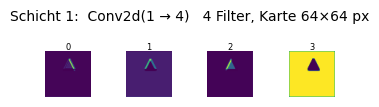

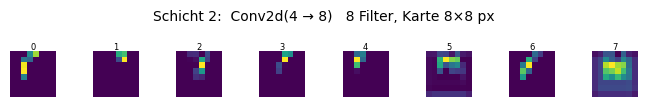

In [201]:
def zeige_schichten(idx, pro_reihe=16):
    """Antwort jedes Filters in JEDER Faltungsschicht auf ein Bild."""
    modell.eval()
    x = X[idx][None]
    schichten = []
    with torch.no_grad():
        for schicht in modell.merkmale:
            x = schicht(x)
            if isinstance(schicht, nn.Conv2d):
                # relu nur fuer die Anzeige; der Durchlauf selbst macht das gleich sowieso
                schichten.append((schicht, torch.relu(x)[0]))

    print(f"Bild: {pfade[idx].name}")
    for nr, (conv, antwort) in enumerate(schichten, 1):
        n, px = antwort.shape[0], antwort.shape[1]
        spalten = min(n, pro_reihe)
        reihen = -(-n // spalten)                        # aufrunden
        fig, axs = plt.subplots(reihen, spalten,
                                figsize=(0.85 * spalten, 1.05 * reihen), squeeze=False)
        for k in range(reihen * spalten):
            ax = axs[k // spalten, k % spalten]
            ax.axis("off")
            if k < n:
                ax.imshow(antwort[k], cmap="viridis")
                ax.set_title(str(k), fontsize=6, pad=1)
        fig.suptitle(f"Schicht {nr}:  Conv2d({conv.in_channels} → {conv.out_channels})   "
                     f"{n} Filter, Karte {px}×{px} px", fontsize=10)
        plt.tight_layout(); plt.show()

zeige_schichten(int(train[0]))

### Interaktiv

Bild durchblättern, Kachelgröße verstellen. Kleine Kachel = feine Details, große Kachel = grobe Regionen und langsamer.

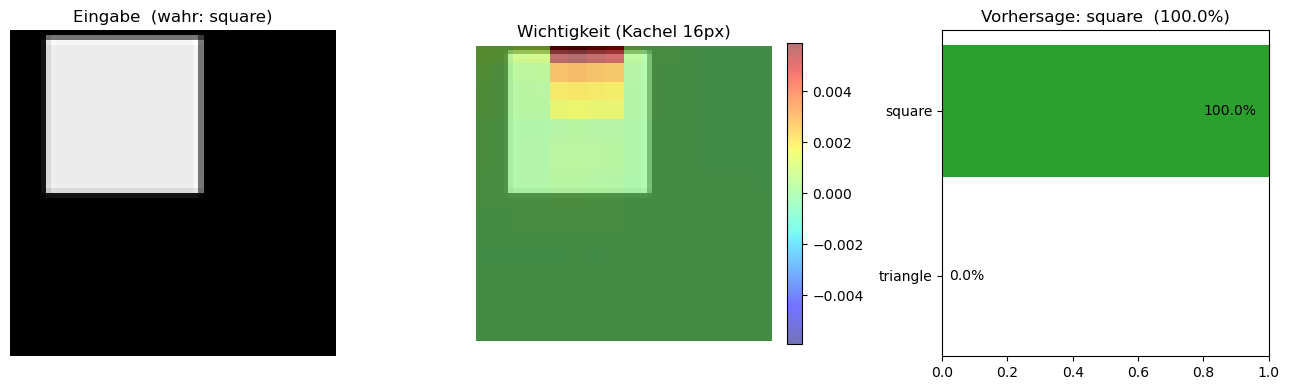

interactive(children=(IntSlider(value=0, description='bild', max=99), IntSlider(value=16, description='kachel'…

In [202]:
from ipywidgets import interact, IntSlider

@interact(bild=IntSlider(0, 0, len(pfade)-1, 1),
          kachel=IntSlider(16, 4, 32, 4))
def demo(bild, kachel):
    fig, achsen = plt.subplots(1, 3, figsize=(13, 4))
    zeige_cnn(bild, kachel, achsen)
    plt.tight_layout(); plt.show()

## 4. Eigenes Bild testen

Die Zelle mit `def teste(...)` legt die Funktion nur an — **da nichts eintragen**, `quelle` ist ein Platzhaltername. Einmal ausführen, danach unten das Pfadfeld benutzen.

**Eigenes Fenster links:** Rechtsklick auf die Ausgabe der Tester-Zelle → *Create New View for Cell Output*, dann den neuen Reiter an den linken Rand ziehen. Er bleibt sichtbar, während du oben weiterscrollst — reines JupyterLab, kein Code nötig.

Pfad einfügen geht auch mit Anführungszeichen (Windows „Als Pfad kopieren"), die werden abgeschnitten.

In [203]:
from io import BytesIO

def teste(quelle, zeigen=True):
    """quelle = Pfad oder Bytes. Gibt (Klasse, Wahrscheinlichkeiten) zurück."""
    daten = quelle if isinstance(quelle, bytes) else Path(quelle).read_bytes()
    roh = np.asarray(Image.open(BytesIO(daten)).convert("L").resize((GROESSE, GROESSE)))
    x = torch.tensor(lade(BytesIO(daten)))[None, None]      # gleiche Normalisierung wie im Training

    modell.eval()
    with torch.no_grad():
        p = modell(x).softmax(1)[0].numpy()
    klasse = int(p.argmax())

    if zeigen:
        if roh.mean() > 127:
            print("Hinweis: heller Hintergrund — trainiert wurde auf helle Form vor dunklem Grund.")
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.2))
        a1.imshow(roh, cmap="gray"); a1.axis("off")
        a1.set_title(f"{KLASSEN[klasse]}   {p[klasse]*100:.1f}%", fontsize=13)
        a2.barh(KLASSEN, p, color="tab:blue")
        a2.set(xlim=(0, 1), xlabel="Wahrscheinlichkeit")
        for k, wert in enumerate(p):
            a2.text(min(wert + .02, .8), k, f"{wert*100:.1f}%", va="center")
        plt.tight_layout(); plt.show()
    return KLASSEN[klasse], p

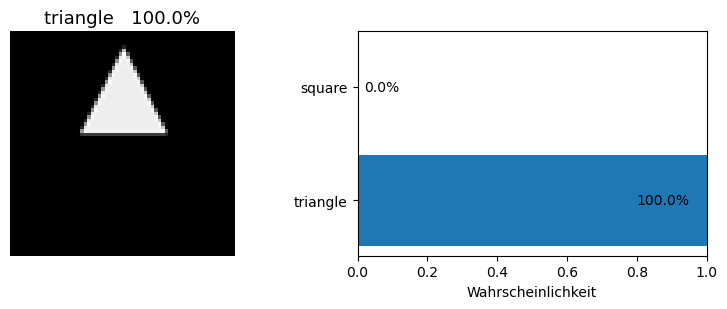

In [204]:
import ipywidgets as w
from IPython.display import display

# continuous_update=False ist wichtig: sonst feuert das Feld bei JEDEM Tastendruck
# und rechnet fuer jeden Zwischenstand des Pfades ein Bild durch. Sieht aus wie haengen.
pfad_feld = w.Text(value=str(pfade[int(test[0])]), placeholder=r"C:\Pfad\zu\bild.png",
                   description="Bild:", continuous_update=False,
                   layout=w.Layout(width="99%"), style={"description_width": "45px"})
knopf   = w.Button(description="Testen", button_style="primary", icon="search")
ausgabe = w.Output()

def pruefen(_=None):
    with ausgabe:
        ausgabe.clear_output(wait=True)
        try:
            teste(pfad_feld.value.strip().strip('"'))   # Anführungszeichen aus "Als Pfad kopieren" wegwerfen
        except Exception as fehler:
            print(f"Geht nicht: {fehler}")

knopf.on_click(pruefen)
pfad_feld.observe(lambda _: pruefen(), names="value")   # feuert bei Enter / Verlassen des Feldes

display(w.VBox([pfad_feld, knopf, ausgabe]))
pruefen()

## Selbstcheck

In [205]:
assert anzahl < 20000,                    f"Netz sollte klein bleiben, ist {anzahl}"
assert verlauf[-1, 0] < verlauf[0, 0],    "Verlust ist nicht gefallen — Training kaputt"
assert genauigkeit(test) > 0.9,           f"Test nur {genauigkeit(test):.2f}"
k = wichtigkeit(X[int(test[0])], int(Y[test[0]]), kachel=16, schritt=8)
assert k.shape == (GROESSE, GROESSE) and np.isfinite(k).all(), "Heatmap kaputt"

karte = modell.merkmale(X[:1])
assert karte.shape[2] > 1 and karte.shape[3] > 1, \
    f"zu oft gepoolt: Karte ist {tuple(karte.shape[2:])} — Global Average Pooling hat nichts zu mitteln"

for ordner, erwartet in [("squares", "square"), ("triangles", "triangle")]:
    p = sorted((DATA/ordner).glob("*.png"))[0]
    aus_pfad, wahrsch = teste(p, zeigen=False)
    aus_bytes, _ = teste(p.read_bytes(), zeigen=False)          # Bytes-Weg muss gleich sein
    assert aus_pfad == erwartet, f"{p.name} -> {aus_pfad}"
    assert aus_bytes == aus_pfad, "Pfad und Bytes liefern Unterschiedliches"
    assert abs(wahrsch.sum() - 1) < 1e-5, "Wahrscheinlichkeiten summieren nicht auf 1"

print("Selbstcheck ok")

AssertionError: zu oft gepoolt: Karte ist (1, 1) — Global Average Pooling hat nichts zu mitteln